# Stage 3: MPS-Native Streaming Validation

Validates MPO-based streaming for **both snake and interleaved mappings**.

**Key finding:** Both mappings achieve chi=2 shift MPOs for all D2Q9 directions.
The advantage of interleaved is in *state* compression (distributed bonds), not operator complexity.

### Sections
1. Setup & Mapping Overview
2. MPO Bond Dimensions (both mappings)
3. Streaming Correctness (random data, both mappings)
4. Compression Quality by Mapping
5. Streaming on Physical Data
6. Bond Dimension Scaling
7. Hybrid Simulation (vanilla collision + MPO streaming)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from lbm import D2Q9, compute_equilibrium, stream, collide_bgk
from lbm.boundary import apply_bounce_back, apply_bounce_back_moving_top
from lbm.collision import compute_moments
from simulations.lid_driven_cavity import create_cavity_walls
from tn.compression import field_to_qtt, qtt_to_field, compress_populations, decompress_populations
from tn.mapping import _interleave_bits, _deinterleave_bits
from tn_lbm.streaming import (
    stream_population_2d, stream_all_populations, stream_dense_2d,
    _build_shift_mpo_2d_interleaved, _build_shift_mpo_2d_snake
)

velocity_names = ['Rest', 'East', 'North', 'West', 'South', 'NE', 'NW', 'SW', 'SE']

print("All modules loaded successfully")

All modules loaded successfully


## 1. Mapping Overview

Two mappings that support chi=2 shift MPOs:

**Snake (row-major):** `I = y*N + x` &rarr; sites 0..L-1 = y-bits, sites L..2L-1 = x-bits (contiguous blocks)

**Interleaved (Z-order):** bits alternate y0 x0 y1 x1 ... (x and y at same scale level)

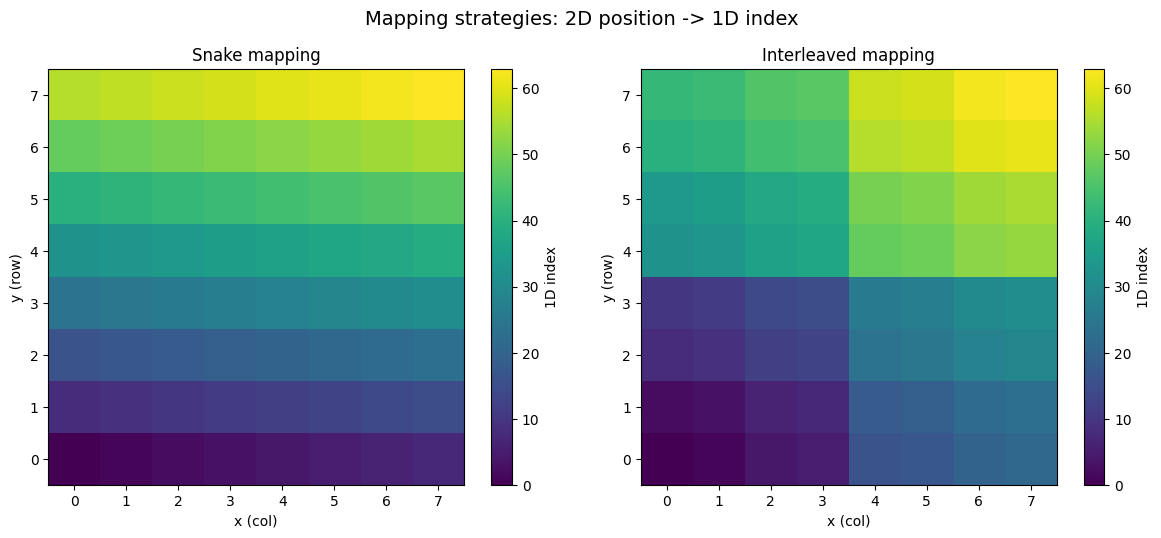

Snake mapping bit structure (8x8, L=3):
  I = y*N + x  =>  bits [y2 y1 y0 | x2 x1 x0]
  Sites 0..2 = y-bits (contiguous), Sites 3..5 = x-bits (contiguous)

Interleaved mapping bit structure (8x8, L=3):
  bits [y2 x2 y1 x1 y0 x0]
  Even sites = y-bits, Odd sites = x-bits (alternating)


In [2]:
def get_mapping_order(n, mapping):
    order = np.zeros((n, n), dtype=int)
    if mapping == 'snake':
        for row in range(n):
            for col in range(n):
                order[row, col] = row * n + col
    elif mapping == 'interleaved':
        L = int(np.log2(n))
        for row in range(n):
            for col in range(n):
                order[row, col] = _interleave_bits(col, row, L)
    return order

n_vis = 8
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mapping in zip(axes, ['snake', 'interleaved']):
    order = get_mapping_order(n_vis, mapping)
    im = ax.imshow(order, cmap='viridis', origin='lower')
    ax.set_title(f'{mapping.capitalize()} mapping', fontsize=12)
    ax.set_xlabel('x (col)'); ax.set_ylabel('y (row)')
    plt.colorbar(im, ax=ax, label='1D index')
plt.suptitle('Mapping strategies: 2D position -> 1D index', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Snake mapping bit structure (8x8, L=3):")
print("  I = y*N + x  =>  bits [y2 y1 y0 | x2 x1 x0]")
print("  Sites 0..2 = y-bits (contiguous), Sites 3..5 = x-bits (contiguous)")
print()
print("Interleaved mapping bit structure (8x8, L=3):")
print("  bits [y2 x2 y1 x1 y0 x0]")
print("  Even sites = y-bits, Odd sites = x-bits (alternating)")

## 2. MPO Bond Dimensions -- Both Mappings

**Key result:** chi=2 for ALL D2Q9 directions with BOTH mappings.

Note the bond profile difference:
- Snake diagonal: `[2,2,2, 1 ,2,2,2]` -- junction bond=1 between y-block and x-block
- Interleaved diagonal: needs 2 sequential MPOs (each chi=2)

In [17]:
L = 4  # 16x16 grid
total_sites = 2 * L

print(f"Shift MPO Bond Dimensions (Grid: {2**L}x{2**L}, Sites: {total_sites})")
print("=" * 80)
print(f"{'Pop':>3} | {'Name':>6} | {'(cx,cy)':>8} | {'Snake chi':>10} | {'Snake bonds':>25} | {'Intlv chi':>10}")
print("-" * 80)

all_pass = True
for i in range(9):
    cx, cy = int(D2Q9.c[i, 0]), int(D2Q9.c[i, 1])
    name = velocity_names[i]
    if cx == 0 and cy == 0:
        print(f"{i:>3} | {name:>6} | ({cx:+d},{cy:+d})  | {'N/A':>10} | {'N/A':>25} | {'N/A':>10}")
        continue

    snake_mpo = _build_shift_mpo_2d_snake(L, cx, cy)
    snake_bonds = [snake_mpo.bond_size(j, j+1) for j in range(total_sites - 1)]
    snake_chi = max(snake_bonds)

    intlv_result = _build_shift_mpo_2d_interleaved(L, cx, cy)
    if isinstance(intlv_result, tuple):
        intlv_chi = max(max(m.bond_size(j, j+1) for j in range(total_sites-1)) for m in intlv_result)
    else:
        intlv_chi = max(intlv_result.bond_size(j, j+1) for j in range(total_sites-1))

    if snake_chi > 2 or intlv_chi > 2:
        all_pass = False

    print(f"{i:>3} | {name:>6} | ({cx:+d},{cy:+d})  | {snake_chi:>10} | {str(snake_bonds):>25} | {intlv_chi:>10}")

print(f"\nOverall: {'ALL chi=2 for both mappings!' if all_pass else 'FAILURES'}")
print("\nSnake diagonal bonds: [2,2,2,1,2,2,2] - junction bond=1 between y/x blocks")
print("Diagonal is a SINGLE MPO for snake (vs 2 sequential for interleaved)")

Shift MPO Bond Dimensions (Grid: 16x16, Sites: 8)
Pop |   Name |  (cx,cy) |  Snake chi |               Snake bonds |  Intlv chi
--------------------------------------------------------------------------------
  0 |   Rest | (+0,+0)  |        N/A |                       N/A |        N/A
  1 |   East | (+1,+0)  |          2 |     [1, 1, 1, 1, 2, 2, 2] |          2
  2 |  North | (+0,+1)  |          2 |     [2, 2, 2, 1, 1, 1, 1] |          2
  3 |   West | (-1,+0)  |          2 |     [1, 1, 1, 1, 2, 2, 2] |          2
  4 |  South | (+0,-1)  |          2 |     [2, 2, 2, 1, 1, 1, 1] |          2
  5 |     NE | (+1,+1)  |          2 |     [2, 2, 2, 1, 2, 2, 2] |          2
  6 |     NW | (-1,+1)  |          2 |     [2, 2, 2, 1, 2, 2, 2] |          2
  7 |     SW | (-1,-1)  |          2 |     [2, 2, 2, 1, 2, 2, 2] |          2
  8 |     SE | (+1,-1)  |          2 |     [2, 2, 2, 1, 2, 2, 2] |          2

Overall: ALL chi=2 for both mappings!

Snake diagonal bonds: [2,2,2,1,2,2,2] - junction 

## 3. Streaming Correctness -- Random Data

Test with random field (full rank, no compression truncation) to isolate streaming accuracy from compression error.

In [18]:
L_test = 4  # 16x16
n_test = 2**L_test
np.random.seed(42)
random_field = np.random.rand(n_test, n_test)

print(f"Streaming Correctness Test ({n_test}x{n_test} random field)")
print("=" * 75)

for mapping in ['snake', 'interleaved']:
    mps, meta = field_to_qtt(random_field, mapping=mapping)
    print(f"\n{mapping.upper()} (sites={meta['total_sites']}, chi={mps.max_bond()})")
    print(f"{'Pop':>3} | {'Name':>6} | {'(cx,cy)':>8} | {'Max Error':>12} | {'chi after':>10} | {'Status':>6}")
    print("-" * 65)

    all_pass = True
    for i in range(9):
        cx, cy = int(D2Q9.c[i, 0]), int(D2Q9.c[i, 1])
        name = velocity_names[i]

        # Expected: non-cyclic shift matching LBM convention
        # axis-0 shifted by cx, axis-1 shifted by cy
        expected = np.zeros_like(random_field)
        for a0 in range(n_test):
            for a1 in range(n_test):
                s0, s1 = a0 - cx, a1 - cy
                if 0 <= s0 < n_test and 0 <= s1 < n_test:
                    expected[a0, a1] = random_field[s0, s1]

        streamed = stream_population_2d(mps, meta, cx, cy)
        result = qtt_to_field(streamed, meta)

        err = np.max(np.abs(expected - result))
        status = 'PASS' if err < 1e-10 else 'FAIL'
        if err >= 1e-10: all_pass = False
        print(f"{i:>3} | {name:>6} | ({cx:+d},{cy:+d})  | {err:>12.2e} | {streamed.max_bond():>10} | {status:>6}")

    print(f"{'ALL PASS' if all_pass else 'FAILURES'}")

Streaming Correctness Test (16x16 random field)

SNAKE (sites=8, chi=16)
Pop |   Name |  (cx,cy) |    Max Error |  chi after | Status
-----------------------------------------------------------------
  0 |   Rest | (+0,+0)  |     6.99e-15 |         16 |   PASS
  1 |   East | (+1,+0)  |     1.20e-14 |         15 |   PASS
  2 |  North | (+0,+1)  |     1.29e-14 |         15 |   PASS
  3 |   West | (-1,+0)  |     1.02e-14 |         15 |   PASS
  4 |  South | (+0,-1)  |     1.42e-14 |         15 |   PASS
  5 |     NE | (+1,+1)  |     1.31e-14 |         15 |   PASS
  6 |     NW | (-1,+1)  |     1.66e-14 |         15 |   PASS
  7 |     SW | (-1,-1)  |     1.69e-14 |         15 |   PASS
  8 |     SE | (+1,-1)  |     2.03e-14 |         15 |   PASS
ALL PASS

INTERLEAVED (sites=8, chi=16)
Pop |   Name |  (cx,cy) |    Max Error |  chi after | Status
-----------------------------------------------------------------
  0 |   Rest | (+0,+0)  |     1.90e-14 |         16 |   PASS
  1 |   East | (+1,+0) 

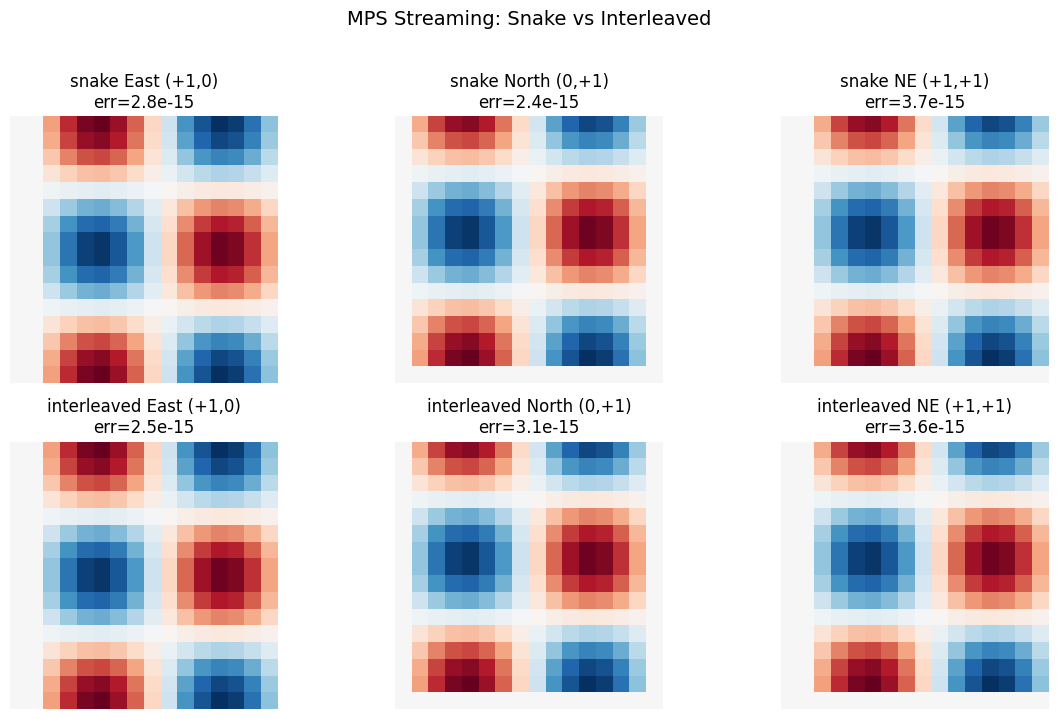

In [19]:
n = 16
x = np.linspace(0, 2*np.pi, n); y = np.linspace(0, 2*np.pi, n)
X, Y = np.meshgrid(x, y, indexing='ij')  # axis-0=x, axis-1=y
test_field = np.sin(X) * np.cos(Y)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
directions = [(1, 0), (0, 1), (1, 1)]
names_dir = ['East (+1,0)', 'North (0,+1)', 'NE (+1,+1)']

for mapping, row in [('snake', 0), ('interleaved', 1)]:
    mps_vis, meta_vis = field_to_qtt(test_field, mapping=mapping)
    for idx, ((cx, cy), dname) in enumerate(zip(directions, names_dir)):
        # Non-cyclic expected: axis-0 by cx, axis-1 by cy
        expected = np.zeros_like(test_field)
        for a0 in range(n):
            for a1 in range(n):
                s0, s1 = a0 - cx, a1 - cy
                if 0 <= s0 < n and 0 <= s1 < n:
                    expected[a0, a1] = test_field[s0, s1]
        streamed_vis = stream_population_2d(mps_vis, meta_vis, cx, cy)
        result_vis = qtt_to_field(streamed_vis, meta_vis)
        err = np.max(np.abs(expected - result_vis))
        axes[row, idx].imshow(result_vis.T, origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
        axes[row, idx].set_title(f'{mapping} {dname}\nerr={err:.1e}')
        axes[row, idx].axis('off')

plt.suptitle('MPS Streaming: Snake vs Interleaved', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 4. Compression Quality by Mapping

Snake has a bond dimension bottleneck at the y/x junction (site L-1 to L), while interleaved distributes correlations across all bonds.

In [20]:
n = 64
x = np.linspace(0, 2*np.pi, n); y = np.linspace(0, 2*np.pi, n)
X, Y = np.meshgrid(x, y)
smooth_field = np.sin(X) * np.cos(Y) + 0.5*np.sin(2*X)*np.cos(2*Y)

print("Compression of smooth sin*cos field (64x64)")
print("=" * 60)
for mapping in ['snake', 'interleaved']:
    mps, meta = field_to_qtt(smooth_field, mapping=mapping)
    total_sites = meta['total_sites']
    bonds = [mps.bond_size(i, i+1) for i in range(total_sites - 1)]
    recon = qtt_to_field(mps, meta)
    err = np.max(np.abs(smooth_field - recon))
    print(f"{mapping:12}: chi={max(bonds):2}, bonds={bonds}")
    print(f"{'':12}  roundtrip error={err:.2e}")

Compression of smooth sin*cos field (64x64)
snake       : chi= 4, bonds=[2, 4, 4, 4, 4, 2, 4, 4, 4, 4, 2]
              roundtrip error=2.89e-15
interleaved : chi= 8, bonds=[2, 4, 8, 8, 8, 8, 8, 8, 8, 4, 2]
              roundtrip error=9.77e-15


In [22]:
n = 64; Re = 100; u_lid = 0.1
nu = u_lid * n / Re; tau = 3*nu + 0.5
walls, lid = create_cavity_walls(n)
u_wall = np.array([u_lid, 0.0])

rho_init = np.ones((n, n)); u_init = np.zeros((2, n, n))
f_vanilla = compute_equilibrium(D2Q9, rho_init, u_init)

print(f"Running vanilla LBM (Re={Re}, {n}x{n})...")
u_prev = u_init.copy()
for t in range(15000):
    f_vanilla = collide_bgk(D2Q9, f_vanilla, tau)
    f_vanilla = stream(D2Q9, f_vanilla)
    f_vanilla = apply_bounce_back(D2Q9, f_vanilla, walls)
    f_vanilla = apply_bounce_back_moving_top(D2Q9, f_vanilla, u_wall)
    rho, u = compute_moments(D2Q9, f_vanilla)
    du = np.max(np.abs(u - u_prev)) / (np.max(np.abs(u)) + 1e-10)
    if du < 1e-5:
        print(f"  Converged at t={t} (du={du:.2e})")
        break
    if t % 2000 == 0: print(f"  t={t}, du={du:.2e}")
    u_prev = u.copy()

rho_vanilla, u_vanilla = compute_moments(D2Q9, f_vanilla)
print(f"  Max velocity: {np.max(np.abs(u_vanilla)):.4f}")

Running vanilla LBM (Re=100, 64x64)...
  t=0, du=1.00e+00
  t=2000, du=1.69e-04
  t=4000, du=3.36e-05
  t=6000, du=1.57e-05
  Converged at t=7035 (du=9.98e-06)
  Max velocity: 0.1001


Bond dimension profiles for cavity flow populations
Pop 0 (  Rest, snake      ): chi=14, err=7.13e-05
Pop 1 (  East, snake      ): chi=18, err=2.52e-05
Pop 2 ( North, snake      ): chi=18, err=1.62e-05
Pop 3 (  West, snake      ): chi=19, err=1.91e-05
Pop 4 ( South, snake      ): chi=18, err=2.42e-05
Pop 5 (    NE, snake      ): chi=19, err=6.75e-06
Pop 6 (    NW, snake      ): chi=19, err=4.62e-06
Pop 7 (    SW, snake      ): chi=20, err=8.41e-06
Pop 8 (    SE, snake      ): chi=19, err=6.98e-06
Pop 0 (  Rest, interleaved): chi=18, err=5.90e-05
Pop 1 (  East, interleaved): chi=22, err=8.94e-06
Pop 2 ( North, interleaved): chi=23, err=1.50e-05
Pop 3 (  West, interleaved): chi=23, err=8.02e-06
Pop 4 ( South, interleaved): chi=25, err=1.25e-05
Pop 5 (    NE, interleaved): chi=24, err=3.64e-06
Pop 6 (    NW, interleaved): chi=24, err=3.93e-06
Pop 7 (    SW, interleaved): chi=27, err=3.03e-06
Pop 8 (    SE, interleaved): chi=26, err=3.75e-06


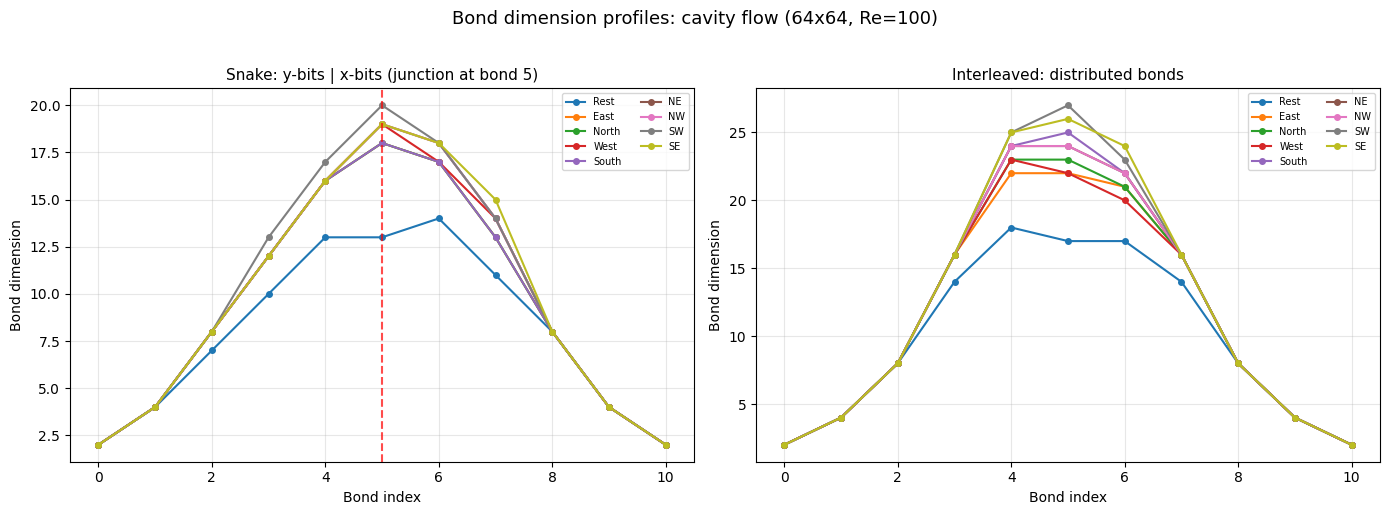

In [23]:
print("Bond dimension profiles for cavity flow populations")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mapping in zip(axes, ['snake', 'interleaved']):
    for i in range(9):
        mps, meta = field_to_qtt(f_vanilla[i], mapping=mapping)
        total_sites = meta['total_sites']
        bonds = [mps.bond_size(j, j+1) for j in range(total_sites - 1)]
        recon = qtt_to_field(mps, meta)
        err = np.max(np.abs(f_vanilla[i] - recon))
        ax.plot(range(len(bonds)), bonds, 'o-', markersize=4, label=f'{velocity_names[i]}')
        print(f"Pop {i} ({velocity_names[i]:>6}, {mapping:11}): chi={max(bonds):2}, err={err:.2e}")

    ax.set_xlabel('Bond index'); ax.set_ylabel('Bond dimension')
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)
    if mapping == 'snake':
        L_coord = total_sites // 2
        ax.axvline(x=L_coord - 1, color='red', linestyle='--', alpha=0.7)
        ax.set_title(f'Snake: y-bits | x-bits (junction at bond {L_coord-1})', fontsize=11)
    else:
        ax.set_title(f'Interleaved: distributed bonds', fontsize=11)

plt.suptitle('Bond dimension profiles: cavity flow (64x64, Re=100)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 5. Streaming on Physical Data

Separate **compression error** from **streaming error**.

Pipeline: `field -> compress (error here) -> stream MPO (exact) -> decompress -> compare`

In [24]:
print("Compression Error vs Streaming Error (cavity flow, selected populations)")
print("=" * 80)

for mapping in ['snake', 'interleaved']:
    print(f"\n{mapping.upper()}:")
    print(f"{'Pop':>3} | {'Name':>6} | {'Compress err':>12} | {'Stream+Compress':>15} | {'Ratio':>6}")
    print("-" * 65)

    for pop_idx in [0, 1, 2, 5]:
        field = f_vanilla[pop_idx]
        cx, cy = int(D2Q9.c[pop_idx, 0]), int(D2Q9.c[pop_idx, 1])
        name = velocity_names[pop_idx]

        mps, meta = field_to_qtt(field, mapping=mapping)
        recon = qtt_to_field(mps, meta)
        compress_err = np.max(np.abs(field - recon))

        # Expected non-cyclic shift: axis-0 by cx, axis-1 by cy
        ny, nx = field.shape
        expected = np.zeros_like(field)
        for a0 in range(ny):
            for a1 in range(nx):
                s0, s1 = a0 - cx, a1 - cy
                if 0 <= s0 < ny and 0 <= s1 < nx:
                    expected[a0, a1] = field[s0, s1]

        streamed = stream_population_2d(mps, meta, cx, cy)
        result = qtt_to_field(streamed, meta)
        total_err = np.max(np.abs(expected - result))

        ratio = total_err / compress_err if compress_err > 0 else float('inf')
        print(f"{pop_idx:>3} | {name:>6} | {compress_err:>12.2e} | {total_err:>15.2e} | {ratio:>6.1f}x")

print("\nRatio ~ 1-2x means streaming adds negligible error beyond compression.")

Compression Error vs Streaming Error (cavity flow, selected populations)

SNAKE:
Pop |   Name | Compress err | Stream+Compress |  Ratio
-----------------------------------------------------------------
  0 |   Rest |     7.13e-05 |        7.13e-05 |    1.0x
  1 |   East |     2.52e-05 |        3.74e-05 |    1.5x
  2 |  North |     1.62e-05 |        1.93e-05 |    1.2x
  5 |     NE |     6.75e-06 |        8.06e-06 |    1.2x

INTERLEAVED:
Pop |   Name | Compress err | Stream+Compress |  Ratio
-----------------------------------------------------------------
  0 |   Rest |     5.90e-05 |        5.90e-05 |    1.0x
  1 |   East |     8.94e-06 |        1.40e-05 |    1.6x
  2 |  North |     1.50e-05 |        2.16e-05 |    1.4x
  5 |     NE |     3.64e-06 |        4.03e-06 |    1.1x

Ratio ~ 1-2x means streaming adds negligible error beyond compression.


## 6. Bond Dimension Scaling

Verify O(log N) memory scaling: MPS sites = 2L = 2*log2(N), and chi stays bounded for smooth data.

In [25]:
grid_sizes = [16, 32, 64, 128, 256]

print("Scaling Analysis (smooth sin*cos field, NE streaming)")
print("=" * 85)
print(f"{'N':>5} | {'N^2':>8} | {'2L sites':>8} | {'Mapping':>11} | {'chi before':>10} | {'chi after':>10} | {'Error':>10}")
print("-" * 85)

results = []
for n in grid_sizes:
    L = int(np.log2(n))
    x = np.linspace(0, 2*np.pi, n); y = np.linspace(0, 2*np.pi, n)
    X, Y = np.meshgrid(x, y, indexing='ij')
    field = np.sin(X) * np.cos(Y)

    # Non-cyclic NE shift: axis-0 by cx=1, axis-1 by cy=1
    expected = np.zeros_like(field)
    for a0 in range(n):
        for a1 in range(n):
            if a0 > 0 and a1 > 0:
                expected[a0, a1] = field[a0-1, a1-1]

    for mapping in ['snake', 'interleaved']:
        mps, meta = field_to_qtt(field, mapping=mapping)
        chi_before = mps.max_bond()
        streamed = stream_population_2d(mps, meta, 1, 1)
        chi_after = streamed.max_bond()
        result = qtt_to_field(streamed, meta)
        err = np.max(np.abs(expected - result))
        results.append({'n': n, 'sites': 2*L, 'mapping': mapping,
                        'chi_before': chi_before, 'chi_after': chi_after})
        print(f"{n:>5} | {n*n:>8} | {2*L:>8} | {mapping:>11} | {chi_before:>10} | {chi_after:>10} | {err:>10.2e}")

Scaling Analysis (smooth sin*cos field, NE streaming)
    N |      N^2 | 2L sites |     Mapping | chi before |  chi after |      Error
-------------------------------------------------------------------------------------
   16 |      256 |        8 |       snake |          2 |          3 |   3.66e-15
   16 |      256 |        8 | interleaved |          4 |          9 |   3.55e-15
   32 |     1024 |       10 |       snake |          2 |          3 |   3.44e-15
   32 |     1024 |       10 | interleaved |          4 |          9 |   5.66e-15
   64 |     4096 |       12 |       snake |          2 |          3 |   5.44e-15
   64 |     4096 |       12 | interleaved |          4 |          9 |   6.22e-15
  128 |    16384 |       14 |       snake |          2 |          3 |   7.88e-15
  128 |    16384 |       14 | interleaved |          4 |          9 |   2.21e-14
  256 |    65536 |       16 |       snake |          2 |          3 |   1.68e-14
  256 |    65536 |       16 | interleaved |       

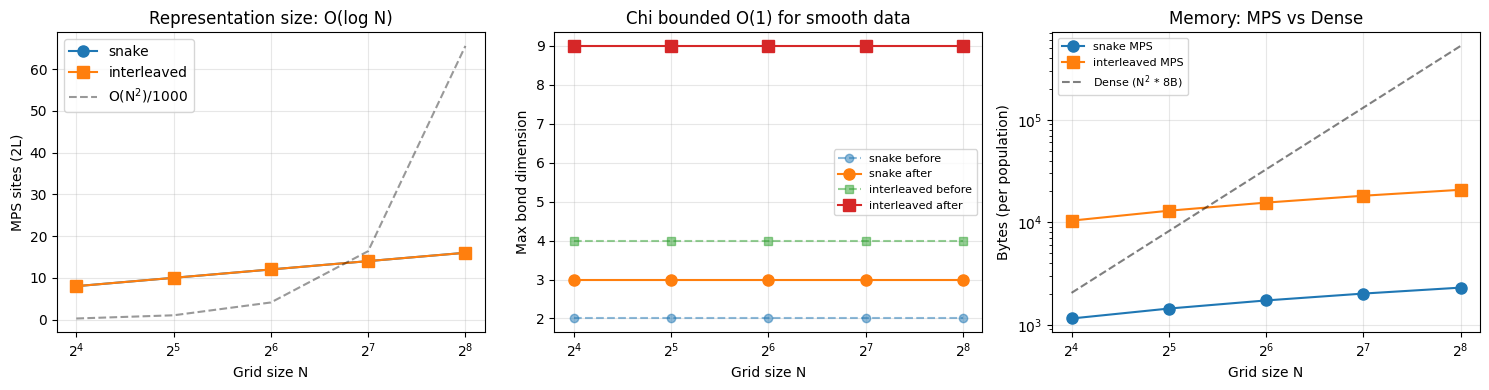

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. MPS sites vs grid size (log scale)
for mapping, marker in [('snake', 'o'), ('interleaved', 's')]:
    rs = [r for r in results if r['mapping'] == mapping]
    ns = [r['n'] for r in rs]
    sites = [r['sites'] for r in rs]
    axes[0].plot(ns, sites, f'{marker}-', markersize=8, label=f'{mapping}')

# Reference: O(N^2) for dense storage
ns_ref = [16, 32, 64, 128, 256]
axes[0].plot(ns_ref, [n**2 / 1000 for n in ns_ref], 'k--', alpha=0.4, label='O(N$^2$)/1000')
axes[0].set_xscale('log', base=2); axes[0].set_xlabel('Grid size N')
axes[0].set_ylabel('MPS sites (2L)'); axes[0].set_title('Representation size: O(log N)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 2. Chi before vs after streaming
for mapping, marker in [('snake', 'o'), ('interleaved', 's')]:
    rs = [r for r in results if r['mapping'] == mapping]
    ns = [r['n'] for r in rs]
    chi_b = [r['chi_before'] for r in rs]
    chi_a = [r['chi_after'] for r in rs]
    axes[1].plot(ns, chi_b, f'{marker}--', markersize=6, alpha=0.5, label=f'{mapping} before')
    axes[1].plot(ns, chi_a, f'{marker}-', markersize=8, label=f'{mapping} after')

axes[1].set_xscale('log', base=2); axes[1].set_xlabel('Grid size N')
axes[1].set_ylabel('Max bond dimension'); axes[1].set_title('Chi bounded O(1) for smooth data')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# 3. Memory comparison: MPS vs dense
for mapping, marker in [('snake', 'o'), ('interleaved', 's')]:
    rs = [r for r in results if r['mapping'] == mapping]
    ns = [r['n'] for r in rs]
    # MPS memory ~ 2L * chi^2 * 2 * 8 bytes (per population)
    mps_mem = [2*int(np.log2(n)) * r['chi_after']**2 * 2 * 8 for n, r in zip(ns, rs)]
    axes[2].plot(ns, mps_mem, f'{marker}-', markersize=8, label=f'{mapping} MPS')

dense_mem = [n**2 * 8 for n in ns_ref]
axes[2].plot(ns_ref, dense_mem, 'k--', alpha=0.5, label='Dense (N$^2$ * 8B)')
axes[2].set_xscale('log', base=2); axes[2].set_yscale('log')
axes[2].set_xlabel('Grid size N'); axes[2].set_ylabel('Bytes (per population)')
axes[2].set_title('Memory: MPS vs Dense'); axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Hybrid Simulation: Chi Sweep Experiment

**Pipeline per timestep:**
```
vanilla collision -> compress(max_bond=chi) -> CYCLIC MPO streaming -> decompress -> bounce-back
```

Run for the same number of steps as vanilla convergence (7035 steps).
Compare both mappings across chi = [12, 14, 16, 18, 20, 24, 28, 32].

In [12]:
# ============================================================
# Step 1: Run vanilla baseline with snapshots
# ============================================================
n = 64; Re = 100; u_lid = 0.1
nu = u_lid * n / Re; tau = 3*nu + 0.5
walls, lid = create_cavity_walls(n)
u_wall = np.array([u_lid, 0.0])

nt_max = 7035  # vanilla converged at this step
snapshot_every = 100

rho_init = np.ones((n, n)); u_init = np.zeros((2, n, n))
f_van = compute_equilibrium(D2Q9, rho_init, u_init)

# Store vanilla snapshots: {timestep: (rho, u)}
van_snapshots = {}
print(f"Running vanilla baseline with snapshots every {snapshot_every} steps...")

u_prev = u_init.copy()
for t in range(nt_max + 1):
    if t > 0:
        f_van = collide_bgk(D2Q9, f_van, tau)
        f_van = stream(D2Q9, f_van)
        f_van = apply_bounce_back(D2Q9, f_van, walls)
        f_van = apply_bounce_back_moving_top(D2Q9, f_van, u_wall)

    if t % snapshot_every == 0 or t == nt_max:
        rho_v, u_v = compute_moments(D2Q9, f_van)
        van_snapshots[t] = (rho_v.copy(), u_v.copy())

    if t % 2000 == 0 and t > 0:
        rho_v, u_v = compute_moments(D2Q9, f_van)
        du = np.max(np.abs(u_v - u_prev)) / (np.max(np.abs(u_v)) + 1e-10)
        print(f"  t={t}, du={du:.2e}")
        u_prev = u_v.copy()

# Store final vanilla state
rho_van_final, u_van_final = van_snapshots[nt_max]
u_van_norm = np.sqrt(u_van_final[0]**2 + u_van_final[1]**2)
print(f"  Done. {len(van_snapshots)} snapshots stored. Max velocity: {np.max(u_van_norm):.4f}")

Running vanilla baseline with snapshots every 100 steps...
  t=2000, du=1.00e+00
  t=4000, du=5.30e-02
  t=6000, du=3.16e-02
  Done. 72 snapshots stored. Max velocity: 0.1001


In [ ]:
# ============================================================
# Step 2: Chi sweep — run hybrid for each (mapping, chi)
# ============================================================
import time

chi_values = [12, 14, 16, 18, 20, 24, 28, 32]
mappings = ['snake', 'interleaved']

# Results: {(mapping, chi): {'t': [...], 'l2_err': [...], 'mass_drift': [...]}}
sweep_results = {}

for mapping in mappings:
    for chi in chi_values:
        label = f"{mapping}/chi={chi}"
        print(f"\n--- {label} ({nt_max} steps) ---", end=" ")
        t_start = time.time()

        f_hyb = compute_equilibrium(D2Q9, rho_init, u_init)
        ts, l2_errs, mass_drifts = [], [], []

        for t in range(nt_max + 1):
            if t > 0:
                # Collision
                f_hyb = collide_bgk(D2Q9, f_hyb, tau)

                # Compress + cyclic MPO stream + decompress
                mps_list, meta = compress_populations(f_hyb, max_bond=chi, mapping=mapping)
                mps_streamed = stream_all_populations(mps_list, meta, D2Q9, cyclic=True)
                f_hyb = decompress_populations(mps_streamed, meta)

                # Bounce-back
                f_hyb = apply_bounce_back(D2Q9, f_hyb, walls)
                f_hyb = apply_bounce_back_moving_top(D2Q9, f_hyb, u_wall)

            # Track at snapshot times
            if t % snapshot_every == 0 or t == nt_max:
                rho_h, u_h = compute_moments(D2Q9, f_hyb)
                rho_v, u_v = van_snapshots[t]

                # Relative L2 velocity error
                u_diff = np.sqrt((u_h[0] - u_v[0])**2 + (u_h[1] - u_v[1])**2)
                u_ref_norm = np.sqrt(u_v[0]**2 + u_v[1]**2)
                l2_err = np.linalg.norm(u_diff) / (np.linalg.norm(u_ref_norm) + 1e-10)

                mass_drift = np.sum(rho_h) - np.sum(rho_v)

                ts.append(t)
                l2_errs.append(l2_err)
                mass_drifts.append(mass_drift)

        elapsed = time.time() - t_start
        print(f"done in {elapsed:.0f}s, final L2 err={l2_errs[-1]:.4f}, mass_drift={mass_drifts[-1]:.1f}")
        sweep_results[(mapping, chi)] = {'t': ts, 'l2_err': l2_errs, 'mass_drift': mass_drifts}

print("\nAll runs completed.")


--- snake/chi=12 (7035 steps) --- done in 556s, final L2 err=0.0086, mass_drift=0.3

--- snake/chi=14 (7035 steps) --- done in 539s, final L2 err=0.0024, mass_drift=0.1

--- snake/chi=16 (7035 steps) --- done in 546s, final L2 err=0.0011, mass_drift=0.0

--- snake/chi=18 (7035 steps) --- done in 557s, final L2 err=0.0010, mass_drift=-0.0

--- snake/chi=20 (7035 steps) --- done in 562s, final L2 err=0.0010, mass_drift=-0.0

--- snake/chi=24 (7035 steps) --- done in 547s, final L2 err=0.0010, mass_drift=-0.0

--- snake/chi=28 (7035 steps) --- done in 542s, final L2 err=0.0010, mass_drift=-0.0

--- snake/chi=32 (7035 steps) --- done in 547s, final L2 err=0.0010, mass_drift=-0.0

--- interleaved/chi=12 (7035 steps) --- done in 1548s, final L2 err=0.0777, mass_drift=1.5

--- interleaved/chi=14 (7035 steps) --- done in 37088s, final L2 err=0.0695, mass_drift=-4.3

--- interleaved/chi=16 (7035 steps) --- done in 1797s, final L2 err=0.0108, mass_drift=-1.4

--- interleaved/chi=18 (7035 steps)

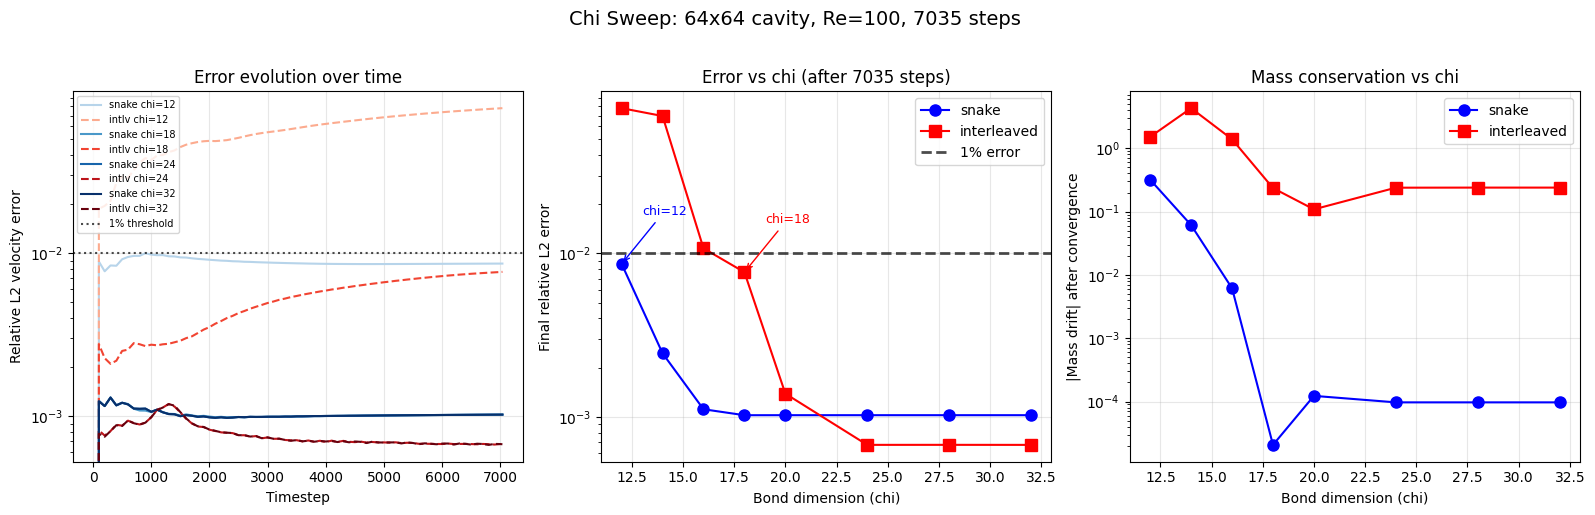


Summary: Final L2 error after 7035 steps
  chi | Snake L2 err | Intlv L2 err |  Snake <1% |  Intlv <1%
-----------------------------------------------------------------
   12 |       0.0086 |       0.0777 |        YES |         no
   14 |       0.0024 |       0.0695 |        YES |         no
   16 |       0.0011 |       0.0108 |        YES |         no
   18 |       0.0010 |       0.0077 |        YES |        YES
   20 |       0.0010 |       0.0014 |        YES |        YES
   24 |       0.0010 |       0.0007 |        YES |        YES
   28 |       0.0010 |       0.0007 |        YES |        YES
   32 |       0.0010 |       0.0007 |        YES |        YES


In [16]:
# ============================================================
# Step 3: Error vs chi + mass drift plots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors_snake = plt.cm.Blues(np.linspace(0.3, 1.0, len(chi_values)))
colors_intlv = plt.cm.Reds(np.linspace(0.3, 1.0, len(chi_values)))

# --- Plot 1: L2 error over time for selected chi values ---
ax = axes[0]
for idx, chi in enumerate(chi_values):
    if chi in [12, 18, 24, 32]:  # only plot a few to avoid clutter
        r_s = sweep_results[('snake', chi)]
        r_i = sweep_results[('interleaved', chi)]
        ax.semilogy(r_s['t'], r_s['l2_err'], '-', color=colors_snake[idx], label=f'snake chi={chi}')
        ax.semilogy(r_i['t'], r_i['l2_err'], '--', color=colors_intlv[idx], label=f'intlv chi={chi}')

ax.axhline(0.01, color='black', linestyle=':', alpha=0.7, label='1% threshold')
ax.set_xlabel('Timestep'); ax.set_ylabel('Relative L2 velocity error')
ax.set_title('Error evolution over time'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# --- Plot 2: Final L2 error vs chi (THE KEY PLOT) ---
ax = axes[1]
final_errs_snake = [sweep_results[('snake', chi)]['l2_err'][-1] for chi in chi_values]
final_errs_intlv = [sweep_results[('interleaved', chi)]['l2_err'][-1] for chi in chi_values]

ax.semilogy(chi_values, final_errs_snake, 'bo-', markersize=8, label='snake')
ax.semilogy(chi_values, final_errs_intlv, 'rs-', markersize=8, label='interleaved')
ax.axhline(0.01, color='black', linestyle='--', linewidth=2, alpha=0.7, label='1% error')
ax.set_xlabel('Bond dimension (chi)'); ax.set_ylabel('Final relative L2 error')
ax.set_title(f'Error vs chi (after {nt_max} steps)')
ax.legend(); ax.grid(True, alpha=0.3)

# Annotate minimum chi for 1%
for mapping, errs, color in [('snake', final_errs_snake, 'blue'), ('interleaved', final_errs_intlv, 'red')]:
    for i, (chi, err) in enumerate(zip(chi_values, errs)):
        if err < 0.01:
            ax.annotate(f'chi={chi}', xy=(chi, err), fontsize=9, color=color,
                       xytext=(chi+1, err*2), arrowprops=dict(arrowstyle='->', color=color))
            break

# --- Plot 3: Mass drift vs chi ---
ax = axes[2]
final_mass_snake = [abs(sweep_results[('snake', chi)]['mass_drift'][-1]) for chi in chi_values]
final_mass_intlv = [abs(sweep_results[('interleaved', chi)]['mass_drift'][-1]) for chi in chi_values]

ax.semilogy(chi_values, final_mass_snake, 'bo-', markersize=8, label='snake')
ax.semilogy(chi_values, final_mass_intlv, 'rs-', markersize=8, label='interleaved')
ax.set_xlabel('Bond dimension (chi)'); ax.set_ylabel('|Mass drift| after convergence')
ax.set_title(f'Mass conservation vs chi'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Chi Sweep: 64x64 cavity, Re={Re}, {nt_max} steps', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Summary table
print(f"\nSummary: Final L2 error after {nt_max} steps")
print("=" * 65)
print(f"{'chi':>5} | {'Snake L2 err':>12} | {'Intlv L2 err':>12} | {'Snake <1%':>10} | {'Intlv <1%':>10}")
print("-" * 65)
for i, chi in enumerate(chi_values):
    s_err = final_errs_snake[i]
    i_err = final_errs_intlv[i]
    s_ok = 'YES' if s_err < 0.01 else 'no'
    i_ok = 'YES' if i_err < 0.01 else 'no'
    print(f"{chi:>5} | {s_err:>12.4f} | {i_err:>12.4f} | {s_ok:>10} | {i_ok:>10}")

In [ ]:
# ============================================================
# Step 4: Velocity field comparison at best chi
# ============================================================
# Find minimum chi that achieves <1% error for each mapping
best_chi = {}
for mapping, errs in [('snake', final_errs_snake), ('interleaved', final_errs_intlv)]:
    for chi, err in zip(chi_values, errs):
        if err < 0.01:
            best_chi[mapping] = chi
            break
    else:
        best_chi[mapping] = chi_values[-1]  # fallback to largest

print(f"Minimum chi for <1% error:  snake={best_chi['snake']}, interleaved={best_chi['interleaved']}")

# Re-run the best chi cases to get final fields (or use sweep data)
# For velocity comparison, re-run just the best interleaved
chi_show = best_chi.get('snake', 24)
f_show = compute_equilibrium(D2Q9, rho_init, u_init)
for t in range(1, nt_max + 1):
    f_show = collide_bgk(D2Q9, f_show, tau)
    mps_list, meta = compress_populations(f_show, max_bond=chi_show, mapping='snake')
    mps_streamed = stream_all_populations(mps_list, meta, D2Q9, cyclic=True)
    f_show = decompress_populations(mps_streamed, meta)
    f_show = apply_bounce_back(D2Q9, f_show, walls)
    f_show = apply_bounce_back_moving_top(D2Q9, f_show, u_wall)
    if t % 2000 == 0:
        print(f"  Re-running snake chi={chi_show}: t={t}")

rho_show, u_show = compute_moments(D2Q9, f_show)
speed_van = np.sqrt(u_van_final[0]**2 + u_van_final[1]**2)
speed_hyb = np.sqrt(u_show[0]**2 + u_show[1]**2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vmax = max(speed_van.max(), speed_hyb.max())
im0 = axes[0].imshow(speed_van.T, origin='lower', cmap='viridis', vmin=0, vmax=vmax)
axes[0].set_title(f'Vanilla LBM (converged)'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(speed_hyb.T, origin='lower', cmap='viridis', vmin=0, vmax=vmax)
axes[1].set_title(f'Hybrid snake chi={chi_show}'); plt.colorbar(im1, ax=axes[1])
diff = np.abs(speed_van - speed_hyb)
im2 = axes[2].imshow(diff.T, origin='lower', cmap='hot')
axes[2].set_title(f'|Difference| (max={diff.max():.2e})'); plt.colorbar(im2, ax=axes[2])
for ax in axes: ax.axis('off')
plt.suptitle(f'Converged velocity fields: vanilla vs hybrid (snake chi={chi_show})', y=1.02)
plt.tight_layout()
plt.show()

# Centerline profiles (classic cavity benchmark)
mid_x = n // 2
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_coords = np.linspace(0, 1, n)
x_coords = np.linspace(0, 1, n)

axes[0].plot(u_van_final[0, mid_x, :] / u_lid, y_coords, 'k-', linewidth=2, label='Vanilla')
axes[0].plot(u_show[0, mid_x, :] / u_lid, y_coords, 'b--', linewidth=2, label=f'Hybrid chi={chi_show}')
axes[0].set_xlabel('u_x / u_lid'); axes[0].set_ylabel('y / L')
axes[0].set_title('Horizontal velocity at x=0.5'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

mid_y = n // 2
axes[1].plot(x_coords, u_van_final[1, :, mid_y] / u_lid, 'k-', linewidth=2, label='Vanilla')
axes[1].plot(x_coords, u_show[1, :, mid_y] / u_lid, 'b--', linewidth=2, label=f'Hybrid chi={chi_show}')
axes[1].set_xlabel('x / L'); axes[1].set_ylabel('u_y / u_lid')
axes[1].set_title('Vertical velocity at y=0.5'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Centerline velocity profiles', y=1.02)
plt.tight_layout()
plt.show()

Minimum chi for <1% error:  snake=12, interleaved=18
